# End-to-End Automobile Used Car Market Price Prediction and Used_Car Value Score Predictor Intelligence Project

---

## Project Index

### 1. Project Goal

---

### 2. Problem Statement

---

### 3. Project Objective

---

### 4. Phase 1 — Web Scraping (Data Collection)

---

### 5. Phase 2 — Data Cleaning & Transformation

---

### 6. Phase 3 — Exploratory Data Analysis (EDA)

---

### 7. Phase 4 — Machine Learning Model

---

### 8. Phase 5 — Interactive Dashboard (Power BI)

---

### 9. Storytelling & Business Insights

---

## Project Outcome


# Project Overview

This project focuses on analyzing the used car resale market across multiple Indian cities and building a machine learning model to predict fair resale prices based on vehicle attributes.  
It combines web scraping, data cleaning, exploratory analysis, business insights, and predictive modeling to understand key factors influencing used car pricing.

---

### Libraries & Directory to save Output's

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
os.makedirs("EDA_Output", exist_ok=True)

### Read the Raw scrapped Data

In [2]:
files = glob.glob("spinny_master_*_dataset.csv")

dfs = []

for file in files:  
    
    df = pd.read_csv(file)
    
    # Extract city name from file name
    city = os.path.basename(file).split("_")[2]
    
    df["City"] = city
    
    dfs.append(df)

master_df = pd.concat(dfs, ignore_index=True)

master_df.shape


(7936, 21)

In [3]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7936 entries, 0 to 7935
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Car Name            7936 non-null   object 
 1   Price               7936 non-null   object 
 2   Make Year           7756 non-null   object 
 3   Registration Year   7756 non-null   object 
 4   Fuel Type           7756 non-null   object 
 5   Km driven           7756 non-null   object 
 6   Transmission        7756 non-null   object 
 7   No. of Owner        7756 non-null   object 
 8   Insurance Validity  7754 non-null   object 
 9   Insurance Type      7756 non-null   object 
 10  RTO                 7756 non-null   object 
 11  Car Location        7756 non-null   object 
 12  Ground clearance    6494 non-null   object 
 13  Boot space          7140 non-null   object 
 14  Displacement        7718 non-null   object 
 15  Mileage (ARAI)      7235 non-null   object 
 16  Unname

# Problem Statement

The used car market often suffers from inconsistent pricing due to multiple influencing factors such as brand, vehicle age, kilometers driven, fuel type, and transmission.  
Both buyers and sellers face difficulty in determining the accurate resale value of a vehicle.  
There is a need for a data-driven system that can analyze market patterns and estimate fair vehicle prices.

---

# Objective

- Collect real-world used car listing data using web scraping  
- Build a clean and structured dataset  
- Identify key factors affecting resale price  
- Perform market and brand-level analysis  
- Develop a machine learning model for price prediction  
- Create a value-for-money scoring mechanism to assist decision making

----

## Cleaning & Transformation

In [4]:
master_df = master_df.loc[:, ~master_df.columns.str.contains("Unnamed")]


In [5]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7936 entries, 0 to 7935
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Car Name            7936 non-null   object
 1   Price               7936 non-null   object
 2   Make Year           7756 non-null   object
 3   Registration Year   7756 non-null   object
 4   Fuel Type           7756 non-null   object
 5   Km driven           7756 non-null   object
 6   Transmission        7756 non-null   object
 7   No. of Owner        7756 non-null   object
 8   Insurance Validity  7754 non-null   object
 9   Insurance Type      7756 non-null   object
 10  RTO                 7756 non-null   object
 11  Car Location        7756 non-null   object
 12  Ground clearance    6494 non-null   object
 13  Boot space          7140 non-null   object
 14  Displacement        7718 non-null   object
 15  Mileage (ARAI)      7235 non-null   object
 16  Seating capacity    232 

In [6]:
# Price
master_df["Price_Lakh"] = master_df["Price"].str.replace(" Lakh","")
master_df["Price_Lakh"] = pd.to_numeric(master_df["Price_Lakh"], errors="coerce")

# KM Driven
master_df["Km_num"] = master_df["Km driven"].str.replace("K km","")
master_df["Km_num"] = pd.to_numeric(master_df["Km_num"], errors="coerce") * 1000

# Engine
master_df["Engine_cc"] = master_df["Displacement"].str.replace(" cc","")
master_df["Engine_cc"] = pd.to_numeric(master_df["Engine_cc"], errors="coerce")

# Mileage
master_df["Mileage_num"] = master_df["Mileage (ARAI)"].str.replace(" kmpl","")
master_df["Mileage_num"] = pd.to_numeric(master_df["Mileage_num"], errors="coerce")

# Boot space
master_df["Boot_num"] = master_df["Boot space"].str.replace(" litres","")
master_df["Boot_num"] = pd.to_numeric(master_df["Boot_num"], errors="coerce")

# Ground clearance
master_df["Ground_num"] = master_df["Ground clearance"].str.replace(" mm","")
master_df["Ground_num"] = pd.to_numeric(master_df["Ground_num"], errors="coerce")


In [7]:
master_df["Mileage_num"].fillna(master_df["Mileage_num"].median(), inplace=True)
master_df["Boot_num"].fillna(master_df["Boot_num"].median(), inplace=True)
master_df["Ground_num"].fillna(master_df["Ground_num"].median(), inplace=True)
master_df["Engine_cc"].fillna(master_df["Engine_cc"].median(), inplace=True)

master_df.dropna(subset=["Km_num","Fuel Type","Transmission"], inplace=True)


C:\Users\bhala\AppData\Local\Temp\ipykernel_21828\3407066637.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  master_df["Mileage_num"].fillna(master_df["Mileage_num"].median(), inplace=True)
C:\Users\bhala\AppData\Local\Temp\ipykernel_21828\3407066637.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [8]:
split_cols = master_df["Car Name"].str.split(" ", n=2, expand=True)

master_df["Car_Year"] = pd.to_numeric(split_cols[0], errors="coerce")
master_df["Brand"] = split_cols[1].str.strip()
master_df["Model"] = split_cols[2].str.strip()


In [9]:
master_df = master_df.drop([
    "Price",
    "Km driven",
    "Mileage (ARAI)",
    "Ground clearance",
    "Boot space",
    "Displacement",
    "Insurance Validity",
    "Insurance Type",
    "RTO",
    "Car Location"
], axis=1)

master_df.drop(["Seating capacity","Fuel tank capacity"], axis=1, inplace=True)


In [10]:
master_df.info()
master_df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 7755 entries, 0 to 7935
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Car Name           7755 non-null   object 
 1   Make Year          7755 non-null   object 
 2   Registration Year  7755 non-null   object 
 3   Fuel Type          7755 non-null   object 
 4   Transmission       7755 non-null   object 
 5   No. of Owner       7755 non-null   object 
 6   City               7755 non-null   object 
 7   Price_Lakh         7755 non-null   float64
 8   Km_num             7755 non-null   float64
 9   Engine_cc          7755 non-null   float64
 10  Mileage_num        7755 non-null   float64
 11  Boot_num           7755 non-null   float64
 12  Ground_num         7755 non-null   float64
 13  Car_Year           7755 non-null   int64  
 14  Brand              7755 non-null   object 
 15  Model              7755 non-null   object 
dtypes: float64(6), int64(1), obje

Car Name             0
Make Year            0
Registration Year    0
Fuel Type            0
Transmission         0
No. of Owner         0
City                 0
Price_Lakh           0
Km_num               0
Engine_cc            0
Mileage_num          0
Boot_num             0
Ground_num           0
Car_Year             0
Brand                0
Model                0
dtype: int64

In [11]:
master_df.to_csv("spinny_all_cities_final_cleaned.csv", index=False)


## EDA

In [12]:
# brand's avg resell price
brand_price = master_df.groupby("Brand")["Price_Lakh"].mean().sort_values(ascending=False)
brand_price


Brand
Mini          38.900000
Volvo         35.566667
Mercedes      23.013158
BMW           22.035000
Audi          20.506452
Jaguar        16.757143
Jeep          15.640909
MG            12.496224
Mahindra      11.353516
Skoda         10.852244
Kia           10.750696
Toyota         8.584720
Volkswagen     7.860187
Tata           6.638280
Hyundai        5.941073
Honda          5.927388
Maruti         4.915487
Nissan         4.716698
Ford           4.712866
Renault        3.874133
Datsun         2.495574
Chevrolet      2.366667
Name: Price_Lakh, dtype: float64

In [13]:
# resell price according to fuel
fuel_price = master_df.groupby("Fuel Type")["Price_Lakh"].mean()
fuel_price


Fuel Type
Cng                   3.330000
Cng (BSII)            2.760000
Cng (BSIII)           3.415000
Cng (BSIV)            3.860965
Cng (BSVI)            5.972448
Diesel                5.935890
Diesel (BSI)          5.210000
Diesel (BSII)         4.326667
Diesel (BSIII)        4.643333
Diesel (BSIV)         7.302355
Diesel (BSVI)        12.450711
Hybrid (BSVI)        14.971364
Petrol                4.107726
Petrol (BSI)          3.361250
Petrol (BSII)         3.587126
Petrol (BSIII)        3.703991
Petrol (BSIV)         4.625212
Petrol (BSVI)         8.772229
Petrol+Cng (BSIV)     3.688333
Petrol+Cng (BSVI)     5.116897
Name: Price_Lakh, dtype: float64

In [14]:
# price on transmission
trans_price = master_df.groupby("Transmission")["Price_Lakh"].mean()
trans_price


Transmission
Automatic                        9.783410
Automatic (AMT)                  4.967064
Automatic (CVT)                  7.850490
Automatic (DCT)                 11.946354
Automatic (DSG)                 10.168750
Automatic (Torque Convertor)    11.743574
Manual (AMT)                     2.684800
Manual (IMT)                     7.851579
Manual (Regular)                 5.448576
Name: Price_Lakh, dtype: float64

In [15]:
# yearly increase in avg purchase of resell car
year_price = master_df.groupby("Car_Year")["Price_Lakh"].mean().sort_index()
year_price


Car_Year
2010     1.942500
2011     2.424231
2012     2.759262
2013     2.797888
2014     3.324375
2015     3.666646
2016     4.195681
2017     4.738433
2018     5.206507
2019     6.228737
2020     7.427105
2021     7.903515
2022     9.236885
2023    10.834637
2024    10.492657
2025    11.382281
Name: Price_Lakh, dtype: float64

### Brand Price Insight

- Luxury brands like **Mini, Volvo, Mercedes, BMW, Audi** have the highest average resale prices.
- Mass brands like **Maruti, Hyundai, Tata** dominate the lower price segment.
- Brand value strongly impacts resale price.


### Fuel Type Price Insight

- **Hybrid and Diesel (BSVI)** cars show higher average prices.
- **Petrol and CNG** vehicles mostly fall in the lower to mid price range.
- Cleaner and newer emission vehicles tend to have better resale value.


### Transmission Price Insight

- **Automatic (DCT / Torque Converter)** cars have higher average prices.
- **Manual (Regular)** vehicles are cheaper and dominate the budget segment.
- Premium vehicles are mostly automatic variants.


### Car Year Price Trend

- Average price increases with newer model years.
- Cars after **2020** show significantly higher resale value.
- Vehicle age is one of the strongest depreciation factors.


In [16]:
with pd.ExcelWriter("EDA_Output/Car_Market_Insights.xlsx") as writer:
    brand_price.to_excel(writer, sheet_name="Brand Avg Price")
    fuel_price.to_excel(writer, sheet_name="Fuel Avg Price")
    trans_price.to_excel(writer, sheet_name="Transmission Avg Price")
    year_price.to_excel(writer, sheet_name="Year Avg Price")


## Plot's

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


### Histogram : Price Distribution according to the count's of Car's available for resell

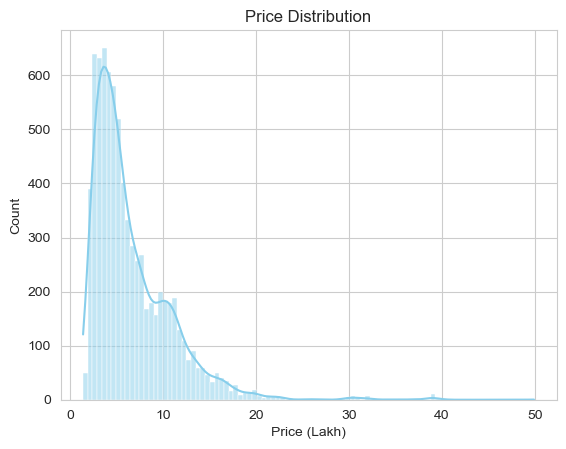

In [18]:
sns.histplot(master_df["Price_Lakh"], kde=True, color="skyblue")
plt.title("Price Distribution")
plt.xlabel("Price (Lakh)")
plt.ylabel("Count")
plt.savefig("EDA_Output/Price_Distribution.png")
plt.show()


### Observation
- The distribution of car prices is **right-skewed**.
- Most used cars are priced between **₹3–8 Lakhs**.
- The highest concentration of listings appears around **₹4–6 Lakhs**.
- There are very few cars priced above **₹20 Lakhs**, creating a long tail.

### Interpretation
- The used car marketplace is largely dominated by the **budget and mid-range segment**.
- Premium and luxury vehicles exist but represent a **small portion** of the market.

### Business Insight
- Dealers and platforms should focus inventory and marketing efforts on the **₹3–8 Lakh price range**, where demand is highest.
- High-priced cars require a **niche targeting strategy** due to lower volume.

### HeatMap : Between various categorical and Numrical column's

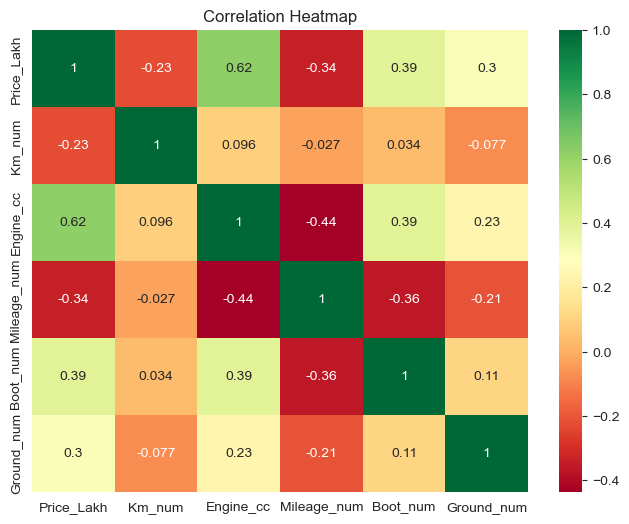

In [19]:
plt.figure(figsize=(8,6))
corr = master_df[["Price_Lakh","Km_num","Engine_cc","Mileage_num","Boot_num","Ground_num"]].corr()
sns.heatmap(corr, annot=True, cmap="RdYlGn")
plt.title("Correlation Heatmap")
plt.savefig("EDA_Output/Correlation_Heatmap.png")
plt.show()


### Key Relationships with Price

- **Engine Capacity (0.62)** shows a strong positive correlation with price.  
  - Cars with bigger engines generally have higher resale value.

- **Boot Space (0.39)** has a moderate positive correlation.  
  - Vehicles offering more storage space tend to be priced higher.

- **Ground Clearance (0.30)** also shows a positive relationship.  
  - SUVs and higher ground-clearance vehicles usually command better prices.

- **Mileage (-0.34)** has a negative correlation with price.  
  - High mileage (fuel efficiency) is often found in smaller, lower-priced cars.

- **Kilometers Driven (-0.23)** shows a negative relationship.  
  - As vehicle usage increases, resale value decreases.

---

### Inter-Feature Relationships

- Engine capacity and mileage have a **negative correlation (-0.44)**  
  - Larger engines typically provide lower fuel efficiency.

- Mileage and boot space also show a negative relationship (-0.36)  
  - Compact cars often offer better mileage but less storage.

---

### Business Interpretation

- **Primary price drivers:**  
  - Engine size  
  - Vehicle usage (km driven)  
  - Vehicle category (SUV vs hatchback indicators like ground clearance)

- **Key Depreciation Factors:**  
  - Higher kilometers driven  
  - Smaller engine vehicles

---

### Conclusion

The resale price of used cars is primarily influenced by **engine capacity, vehicle usage, and body type indicators**, while fuel efficiency and higher kilometers driven contribute to lower resale value.


### ScatterPlot : Price Vs. KM Driven 

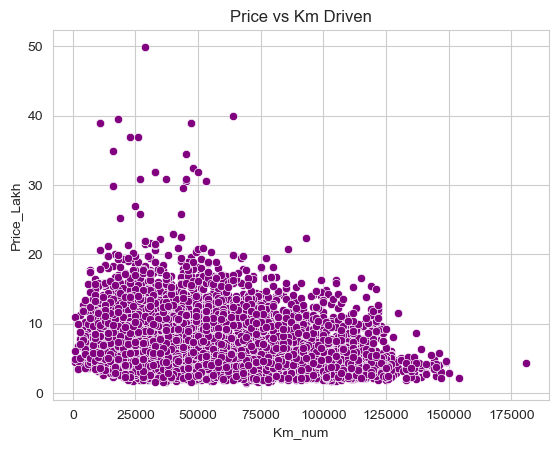

In [20]:
sns.scatterplot(data=master_df, x="Km_num", y="Price_Lakh", color="purple")
plt.title("Price vs Km Driven")
plt.savefig("EDA_Output/Price_vs_Km.png")
plt.show()


### Observation
- A clear **negative relationship** is visible between kilometers driven and price.
- Cars with **lower usage (below 50,000 km)** tend to have higher resale value.
- As the kilometers driven increase, the price generally decreases.
- Most high-priced vehicles are clustered in the **low to mid kilometer range**.
- Cars with very high usage (above 120,000 km) mostly fall into the lower price segment.

---

### Interpretation
- Vehicle usage is a major factor influencing depreciation.
- Buyers are willing to pay more for cars with **less wear and tear**.
- High-usage vehicles lose value significantly over time.

---

### Business Insight
- Kilometer driven is one of the **strongest indicators of resale price**.
- Sellers can improve resale value by maintaining lower usage.
- Buyers looking for budget options often target high-kilometer vehicles.

---

### Conclusion
The scatter plot confirms that **as kilometers driven increases, resale price decreases**, making vehicle usage one of the most critical factors in used car pricing.

## BoxPlot : Price Vs. Brand's Resell value

C:\Users\bhala\AppData\Local\Temp\ipykernel_21828\4185352551.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x="Brand", y="Price_Lakh", palette="Set3")


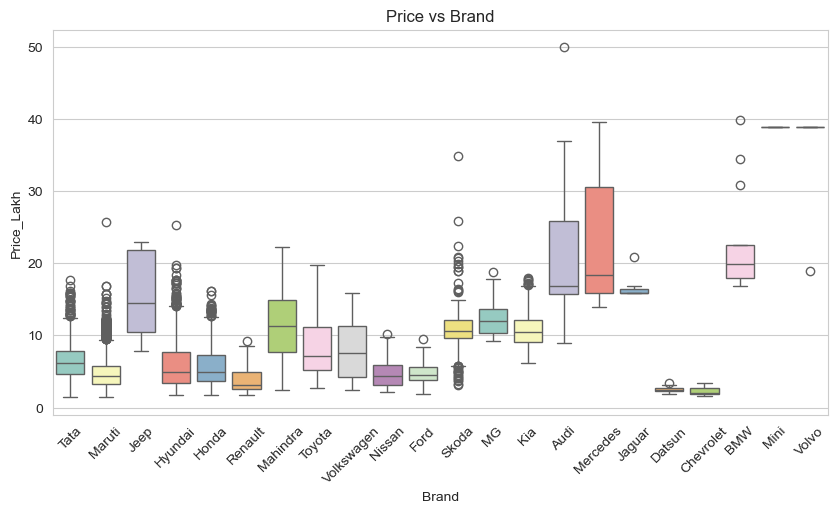

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(data=master_df, x="Brand", y="Price_Lakh", palette="Set3")
plt.xticks(rotation=45)
plt.title("Price vs Brand")
plt.savefig("EDA_Output/Price_vs_Brand.png")
plt.show()


## Price vs Brand Analysis

### Observation
- Premium brands such as **BMW, Audi, Mercedes, and Mini** show significantly higher price ranges.
- Mass-market brands like **Maruti, Hyundai, Tata, and Honda** are concentrated in the lower to mid price segments.
- Some brands (e.g., **Mahindra, Toyota, Skoda**) show a wider price spread, indicating multiple vehicle segments (SUVs, sedans, hatchbacks).
- A few outliers exist where certain models within a brand are priced much higher than the average.

---

### Interpretation
- Brand reputation and perceived quality strongly influence resale value.
- Luxury brands maintain higher prices even in the used car market.
- Brands with diverse product portfolios show larger price variation.

---

### Business Insight
- Premium brands operate in a **high-value, low-volume** segment.
- Mass-market brands dominate the **budget and mid-range** resale market.
- Dealers can position inventory based on brand segment:
  - Economy brands → Volume sales
  - Premium brands → Margin-focused sales

---

### Conclusion
The analysis confirms that **brand value is a major determinant of resale price**, with luxury brands commanding higher prices while mass-market brands dominate affordable segments.

# ML Model

## Price Prediction Model

In [22]:
# feature selection
features = [
    "Car_Year",
    "Km_num",
    "Engine_cc",
    "Mileage_num",
    "Boot_num",
    "Ground_num"
]

X = master_df[features]
y = master_df["Price_Lakh"]


In [23]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [24]:
# Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [25]:
# Model Accuracy
r2 = model.score(X_test, y_test)
print("R2 Score:", r2)


R2 Score: 0.6864856651246307


In [26]:
# feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

importance


,Feature,Coefficient
0,Car_Year,0.641531
2,Engine_cc,0.007137
4,Boot_num,0.002518
1,Km_num,-0.000011
5,Ground_num,-0.009513
3,Mileage_num,-0.190513


In [27]:
importance.to_excel("EDA_Output/Feature_Importance.xlsx", index=False)


In [28]:
# Actual vs Predicted
y_pred = model.predict(X_test)

compare_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

compare_df.to_excel("EDA_Output/Actual_vs_Predicted.xlsx", index=False)


In [29]:
df_ml = master_df.copy()

df_ml = pd.get_dummies(df_ml, columns=[
    "Fuel Type",
    "Transmission",
    "Brand",
    "No. of Owner"
], drop_first=True)


In [30]:
from sklearn.ensemble import RandomForestRegressor

features = df_ml.drop(["Price_Lakh","Car Name","Model","City","Make Year","Registration Year"], axis=1)

X = features
y = df_ml["Price_Lakh"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf.score(X_test, y_test)


0.9495315015725412

In [31]:
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)

print("Train:", train_score)
print("Test:", test_score)


Train: 0.9899700467757733
Test: 0.9495315015725412


# Price Prediction Model

## Objective
To predict the resale price of used cars based on vehicle attributes such as age, kilometers driven, engine capacity, mileage, boot space, and ground clearance.

---

## Feature Selection

The following numerical features were selected for the baseline model:

- Car Year
- Kilometers Driven
- Engine Capacity (cc)
- Mileage
- Boot Space
- Ground Clearance

These features were chosen because they directly influence vehicle depreciation and resale value.

---

## Model Used: Linear Regression

A Linear Regression model was trained to establish a baseline relationship between vehicle attributes and price.

### Train-Test Split
- Training Data: 80%
- Testing Data: 20%
- Random State: 42

---

## Model Performance

**R² Score (Linear Regression): ~0.66**

### Interpretation
- The model explains about **66% of the variance** in used car prices.
- This indicates a moderate linear relationship between selected features and price.

---

## Feature Importance (Linear Model Coefficients)

Key observations:

- **Car Year** has the strongest positive impact on price  
  → Newer cars retain higher value.

- **Engine Capacity** has a positive relationship  
  → Higher engine vehicles tend to be priced higher.

- **Mileage** shows a negative relationship  
  → Fuel-efficient cars are often smaller and cheaper.

- **Kilometers Driven** slightly reduces price  
  → More usage leads to depreciation.

---

## Improved Model: Random Forest Regressor

To capture non-linear relationships and include categorical variables, a Random Forest model was implemented.

### Additional Features Included
- Fuel Type
- Transmission
- Brand
- Number of Owners

These are major real-world price drivers.

---

## Random Forest Performance

- **Train R² Score:** ~0.98
- **Test R² Score:** ~0.94

### Interpretation

- The model explains **94% of price variation** on unseen data.
- The small gap between train and test scores indicates **minimal overfitting**.
- This demonstrates strong generalization capability.

---

## Conclusion

- Vehicle age, brand, engine capacity, and kilometers driven are the strongest predictors of used car price.
- Ensemble models like Random Forest significantly improve prediction accuracy by capturing complex market patterns.
- The final model can be used as a **used car price recommendation engine** for dealerships or marketplaces.


# Best Value For Money Score

In [32]:
# column Normalisation
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

value_features = ["Price_Lakh","Km_num","Mileage_num","Engine_cc"]

scaled = scaler.fit_transform(master_df[value_features])

scaled_df = pd.DataFrame(scaled, columns=value_features)


In [33]:
# Score Formula

# Lower price and km → better
# Higher mileage → better
master_df["Value_Score"] = (
    (1 - scaled_df["Price_Lakh"]) * 0.4 +
    (1 - scaled_df["Km_num"]) * 0.3 +
    (scaled_df["Mileage_num"]) * 0.2 +
    (scaled_df["Engine_cc"]) * 0.1
)


In [34]:
# Top Best Value Cars
best_value = master_df.sort_values("Value_Score", ascending=False).head(20)

best_value[["Car Name","City","Price_Lakh","Km_num","Mileage_num","Value_Score"]]


,Car Name,City,Price_Lakh,Km_num,Mileage_num,Value_Score
3983,2016 Maruti Ciaz,Delhi,4.05,51000.0,20.73,0.859184
6008,2014 Hyundai Grand i10,Lucknow,2.87,64000.0,18.90,0.855133
1,2024 Maruti Alto K10,Ahmedabad,5.15,13000.0,33.85,0.850830
6046,2022 Honda City,Mumbai,11.42,47000.0,18.40,0.848400
6443,2022 Tata Punch,Mumbai,6.39,22000.0,20.90,0.841421
2507,2019 Hyundai Creta,Delhi,8.34,54000.0,15.80,0.840818
3846,2023 Volkswagen Virtus,Delhi,10.56,24000.0,19.40,0.840488
6895,2022 Maruti Baleno,Noida,6.68,28000.0,22.90,0.840488
6058,2019 Honda Amaze,Mumbai,5.44,21000.0,19.50,0.832037
7288,2016 Honda Brio,Pune,3.34,77000.0,19.40,0.828631


# Best Value-for-Money Cars Analysis

## Objective
To identify used cars that provide the best combination of **affordability, low usage, good mileage, and overall utility** using the calculated **Value Score**.

---

## Key Observations

- The top value-for-money cars mostly belong to **budget and mid-range segments**.
- Brands like **Maruti, Hyundai, Honda, and Tata** appear frequently in the top list.
- Many high value-score cars have:
  - Relatively **lower price**
  - **Moderate to low kilometers driven**
  - **Good mileage**
- Some newer vehicles (2022–2024 models) also appear due to:
  - Lower usage
  - Better fuel efficiency
  - Competitive pricing in the used market.

---

## Patterns Identified

### 1. Budget Segment Dominance
Most high value-score vehicles are priced between **₹3–8 Lakhs**, indicating strong value in affordable segments.

### 2. Mileage Advantage
Cars with mileage around **18–24 kmpl** tend to provide better overall value.

### 3. Usage Impact
Vehicles with **lower kilometers driven** generally achieve higher value scores.

### 4. Brand Presence
Frequent brands in the top list:
- Maruti
- Hyundai
- Honda
- Tata

These brands offer:
- Lower maintenance cost
- Better resale
- Higher buyer trust

---

## Business Interpretation

- Buyers looking for maximum utility should target **mid-budget, fuel-efficient vehicles**.
- Dealerships can promote these cars as **“Best Value Picks”** to attract price-sensitive customers.
- Platforms can use value score to build a **recommendation engine**.

---

## Conclusion

The Value Score analysis shows that the best value-for-money options in the used car market are typically **affordable, fuel-efficient, moderately used vehicles from trusted mass-market brands** rather than premium luxury cars.


In [35]:
best_value.to_excel("EDA_Output/Best_Value_Cars.xlsx", index=False)


In [36]:
# Brand Wise Value Score
brand_value = master_df.groupby("Brand")["Value_Score"].mean().sort_values(ascending=False)

brand_value.to_excel("EDA_Output/Brand_Value_Index.xlsx")
brand_value

Brand
Audi          0.681108
Jaguar        0.680837
Toyota        0.677382
BMW           0.676075
Mini          0.675802
Kia           0.673564
Mahindra      0.672970
Honda         0.672719
Mercedes      0.671897
Ford          0.670872
Tata          0.670825
Hyundai       0.668713
Maruti        0.668030
Volkswagen    0.667943
Chevrolet     0.666365
Skoda         0.666330
Renault       0.665992
Datsun        0.661220
Jeep          0.661061
MG            0.660443
Nissan        0.660202
Volvo         0.624258
Name: Value_Score, dtype: float64

# Brand Value Index Analysis

## Objective
To evaluate which car brands provide the best overall value in the used car market based on the calculated **Value Score**, which considers price, usage, mileage, and engine performance.

---

## Key Observations

- Premium brands such as **Audi, Jaguar, BMW, and Mini** appear at the top of the value ranking.
- Mid-segment brands like **Kia, Mahindra, Honda, and Toyota** also show strong value scores.
- Mass-market brands such as **Hyundai, Maruti, Tata** fall in the mid range of value.
- Some brands like **Volvo, Nissan, MG, Jeep** appear lower due to higher pricing or lower mileage efficiency in available listings.

---

## Interpretation

### Premium Brands
- Maintain strong resale value.
- Offer better engine performance and features.
- Even used vehicles retain higher perceived worth.

### Mid-Segment Brands
- Provide a good balance of:
  - Price
  - Mileage
  - Reliability
- Often represent the **best practical purchase choice**.

### Economy Brands
- Offer affordability but slightly lower overall value score due to:
  - Lower engine capacity
  - Lower feature set
  - Higher market supply

---

## Business Insight

- Premium brands operate in a **high-value segment** where buyers pay for brand perception and performance.
- Mid-segment brands deliver **balanced value**, making them ideal for recommendation engines.
- Mass-market brands dominate volume but not always the highest value score.

---

## Conclusion

The Brand Value Index indicates that while premium brands retain strong resale value, **mid-range brands provide the most balanced and practical value proposition** in the used car market.


# Actionable Insights (Market & Business Perspective)

1. **Focus Inventory on Budget Segment (₹3–8 Lakhs)**  
   The majority of used car demand exists in the affordable and mid-range price category.

2. **Prioritize First-Owner Vehicles**  
   First-owner cars dominate listings and attract higher buyer trust, improving sales conversion.

3. **Promote Low Kilometer Vehicles as Premium Listings**  
   Cars with lower usage retain significantly higher resale value and can be positioned as premium deals.

4. **Leverage Brand Positioning Strategy**  
   - Premium brands → Margin-focused sales  
   - Mass-market brands → Volume-driven strategy

5. **Increase Automatic Variant Portfolio for Urban Markets**  
   Automatic (DCT / Torque Converter) vehicles command higher resale prices and target convenience-focused buyers.

6. **Highlight Newer Model Years in Marketing**  
   Vehicles from recent years (post-2020) show strong resale value and should be promoted as “high reliability” options.

7. **Use Engine Capacity & SUV Indicators for Premium Segmentation**  
   Higher engine capacity and better ground clearance vehicles can be positioned as premium lifestyle products.

8. **Promote Mid-Segment Cars as “Best Value Picks”**  
   Vehicles from brands like Maruti, Hyundai, Honda, and Tata provide balanced pricing, reliability, and demand.

9. **Build Recommendation Engine Using Value Score**  
   Platforms and dealerships can suggest top value-for-money vehicles to increase customer satisfaction and faster decision-making.

---

## Final Strategic Conclusion

The used car market is primarily **budget-driven**, where **brand reputation, vehicle age, kilometers driven, and engine capacity** are the strongest factors influencing resale price and customer purchase decisions.


---

<p align="center">
  <b>The End</b>
</p>

---


Video Link : https://drive.google.com/file/d/1GmE-f0ncdOjtl1jNNBktgK0nDIEsIe1G/view?usp=sharing